# Visual for Slides — AT3 Pitch Deck Chart Assets

**Purpose:** Produce 7 palette-locked PNG chart assets for the 11-slide AT3 pitch deck.

**What this notebook does:**
- Loads clean CSVs and the SA3 shapefile
- Enforces one palette (Navy / Teal / Gold / Red / Blue-lite) across all charts
- Exports each chart as a 1920×1080 PNG to `slides_deck/assets/`

**What this notebook does NOT do:**
- Callout text, annotation pins, arrows, CTA bands → those are added in Canva
- Screencaps of the running dashboard (S9 thumbnails, S10 dual choropleth) → capture separately
- Any chart for slides S1, S2, S9, S10 → those are text-only or dashboard screencaps

| Slide | Output file |
|-------|-------------|
| S3 | `S3_australia_silhouette.png` |
| S4 | `S4_choropleth_caregap_2024.png` |
| S5 | `S5_ownership_trend_12q.png` |
| S6 | `S6_funding_quality_scatter.png` |
| S7 | `S7_waitlist_top10_2024.png` |
| S8 | `S8_supply_divergence_indexed.png` |
| S11 | `S11_quality_timeline_oct2023.png` |

In [110]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import geopandas as gpd
from pathlib import Path

print(f"pandas  {pd.__version__}")
print(f"geopandas {gpd.__version__}")
print(f"matplotlib {matplotlib.__version__}")

pandas  3.0.2
geopandas 1.1.3
matplotlib 3.10.9


In [111]:
REPO_ROOT  = Path(r"c:\Users\phamm\OneDrive\Documents\GitHub\dvn-at3-aged-care-gap")
DATA_CLEAN = REPO_ROOT / "data" / "clean"
DATA_RAW   = REPO_ROOT / "data" / "raw"
GEO_PATH   = DATA_RAW / "abs_geography" / "SA3_2021_AUST_GDA2020.shp"
OUTPUT_DIR = REPO_ROOT / "slides_deck" / "assets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output dir : {OUTPUT_DIR}")
print(f"Shapefile  : {'EXISTS' if GEO_PATH.exists() else 'MISSING — check path'}")

Output dir : c:\Users\phamm\OneDrive\Documents\GitHub\dvn-at3-aged-care-gap\slides_deck\assets
Shapefile  : EXISTS


## Palette rationale

Each colour is assigned to a **semantic role**, not just a visual one. The same role must be the same colour across every chart in this notebook — that is what makes 7 separate charts read as one coherent deck.

| Colour | Hex | Role | Why |
|--------|-----|------|-----|
| Navy | `#1B3F6E` | Primary brand / axes / dark BG | Deck identity colour |
| Teal | `#00A79D` | Government / solution / action | Govt scores highest → solution accent |
| Gold | `#F5C842` | Annotation / mandate marker / highlight | All Oct 2023 vlines must be gold |
| Red | `#D94F3D` | For-profit / urgency / crisis threshold | Profit = crisis angle in this deck |
| Blue-mid | `#4A7FC1` | Not-for-profit | Between Teal (govt) and Red (profit), numerically and visually |
| Blue-lite | `#E3F1FA` | Soft chart background | Used on "solution" slides |
| Grey-axis | `#6B7280` | Gridlines, tick labels | Neutral — never competes with data |

**Typography:** `DejaVu Sans Bold` is the closest matplotlib-bundled substitute for Montserrat. The user will re-typograph headlines in Canva; chart axis labels in DejaVu Bold are consistent across all slides and platforms.

In [112]:
PALETTE = {
    "navy":      "#1B3F6E",
    "teal":      "#00A79D",
    "gold":      "#F5C842",
    "red":       "#D94F3D",
    "blue_lite": "#E3F1FA",
    "blue_mid":  "#4A7FC1",
    "grey_axis": "#6B7280",
    "grey_bg":   "#F7F9FB",
}

# Org-type colour mapping (matches dashboard ORG_COLOURS)
ORG_COLORS = {
    "government":    PALETTE["teal"],
    "not_for_profit": PALETTE["blue_mid"],
    "profit":        PALETTE["red"],
}
ORG_LABELS = {
    "government":    "Government",
    "not_for_profit": "Not-for-profit",
    "profit":        "For-profit",
}

# Purpose column in star_ratings → normalised org_type
PURPOSE_MAP = {
    "not for profit": "not_for_profit",
    "for profit":     "profit",
    "government":     "government",
}

matplotlib.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.weight":        "bold",
    "axes.labelweight":   "bold",
    "axes.titleweight":   "bold",
    "axes.titlesize":     16,
    "axes.labelsize":     13,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "axes.edgecolor":     PALETTE["grey_axis"],
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         150,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.15,
    "savefig.transparent": False,
    "figure.facecolor":   "white",
})

print("✓ Palette and rcParams configured")
print("  Org colours:", {k: v for k, v in ORG_COLORS.items()})

✓ Palette and rcParams configured
  Org colours: {'government': '#00A79D', 'not_for_profit': '#4A7FC1', 'profit': '#D94F3D'}


## Export helper

`export_png(fig, name)` enforces:
- **9.6 × 5.4 inches at dpi=200** → 1920×1080 pixels (exact 16:9 Canva slide background)
- `bbox_inches='tight'` + `pad_inches=0.15` → no stray whitespace
- Saves to `slides_deck/assets/<name>.png` and prints the file size

In [113]:
def export_png(fig, name: str, width_in: float = 9.6, height_in: float = 5.4) -> Path:
    """Save fig to slides_deck/assets/<name>.png at 1920x1080 equivalent."""
    fig.set_size_inches(width_in, height_in)
    out = OUTPUT_DIR / f"{name}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight", pad_inches=0.15,
                facecolor=fig.get_facecolor(), edgecolor="none")
    kb = out.stat().st_size // 1024
    print(f"  ✓  {out.name}  ({kb} kb)")
    return out

print("✓ export_png helper ready")

✓ export_png helper ready


## Data loading

Six CSVs + the SA3 shapefile. Sanity assertions run immediately after load — if any fail, fix the data before proceeding.

In [114]:
ratings = pd.read_csv(DATA_CLEAN / "star_ratings_by_facility.csv", low_memory=False)
supply  = pd.read_csv(DATA_CLEAN / "service_supply_by_sa3.csv")
users   = pd.read_csv(DATA_CLEAN / "service_users_by_sa3.csv")
funding = pd.read_csv(DATA_CLEAN / "service_funding_by_facility.csv", low_memory=False)
master  = pd.read_csv(DATA_CLEAN / "master_sa3.csv")
gdf     = gpd.read_file(GEO_PATH)

# Normalise ratings snapshot_date and org_type (from Purpose column)
ratings["snapshot_date"] = pd.to_datetime(ratings["snapshot_date"])
ratings["org_type"] = ratings["Purpose"].str.lower().str.strip().map(PURPOSE_MAP)

# Normalise SA3 code dtype across all sources
# Shapefile SA3_CODE21 is loaded as str; CSV sa3_code is float64 → align both to nullable Int64
gdf["SA3_CODE21"] = pd.to_numeric(gdf["SA3_CODE21"], errors="coerce").astype("Int64")
for _df in [ratings, supply, users, funding, master]:
    if "sa3_code" in _df.columns:
        _df["sa3_code"] = pd.to_numeric(_df["sa3_code"], errors="coerce").astype("Int64")

# Sanity checks
assert len(ratings) > 0, "ratings empty"
assert 2024 in master["year"].values, "master_sa3 missing 2024"
assert {"profit", "not_for_profit", "government"}.issubset(set(funding["org_type"].dropna())), "funding org_type values unexpected"
assert GEO_PATH.exists(), f"Shapefile not found: {GEO_PATH}"

n_snapshots = ratings["snapshot_date"].nunique()
print(f"✓ ratings    {len(ratings):,} rows  |  {n_snapshots} snapshots  |  org_types: {ratings['org_type'].value_counts().to_dict()}")
print(f"✓ supply     {len(supply):,} rows  |  years: {sorted(supply['year'].unique())}")
print(f"✓ users      {len(users):,} rows")
print(f"✓ funding    {len(funding):,} rows  |  org_types: {funding['org_type'].value_counts().to_dict()}")
print(f"✓ master     {len(master):,} rows  |  years: {sorted(master['year'].unique())}")
print(f"✓ shapefile  {len(gdf)} polygons  |  SA3_CODE21 dtype: {gdf['SA3_CODE21'].dtype}")

✓ ratings    31,177 rows  |  12 snapshots  |  org_types: {'not_for_profit': 18032, 'profit': 10694, 'government': 2451}
✓ supply     2,307 rows  |  years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
✓ users      1,005 rows
✓ funding    37,733 rows  |  org_types: {'not_for_profit': 22687, 'profit': 10498, 'government': 4548}
✓ master     660 rows  |  years: [np.int64(2023), np.int64(2024)]
✓ shapefile  359 polygons  |  SA3_CODE21 dtype: Int64


---
## S3 — Australia Silhouette (Hook slide)

**WHY this chart for S3:**  
S3 asks "Where is the crisis worst?" and lets the audience answer wrong before flipping their intuition. A geographic silhouette — not a data chart — creates the flip in 2 seconds without any reading. The audience *sees* remote areas glowing gold (high quality) and cities bleeding red (crisis) before a single number is spoken.

**MUST show:**
- Outback / remote zones filled GOLD (MM6, MM7 = high quality)
- Four metro cores filled RED (MM1 = lowest quality)
- Australia continent shape recognisable
- Navy background (matches S3 slide background)

**MUST NOT:**
- Axes, ticks, gridlines, longitude/latitude
- Legend (explained verbally + in the dark inset text on the slide)
- State borders (distracts from the MM-band reading)
- MM2–MM5 distinction (they're grey — only the extremes matter here)

**Source:** `star_ratings_by_facility.csv` → mode `mmm_code` per SA3 → merge to shapefile

  ✓  S3_australia_silhouette.png  (158 kb)


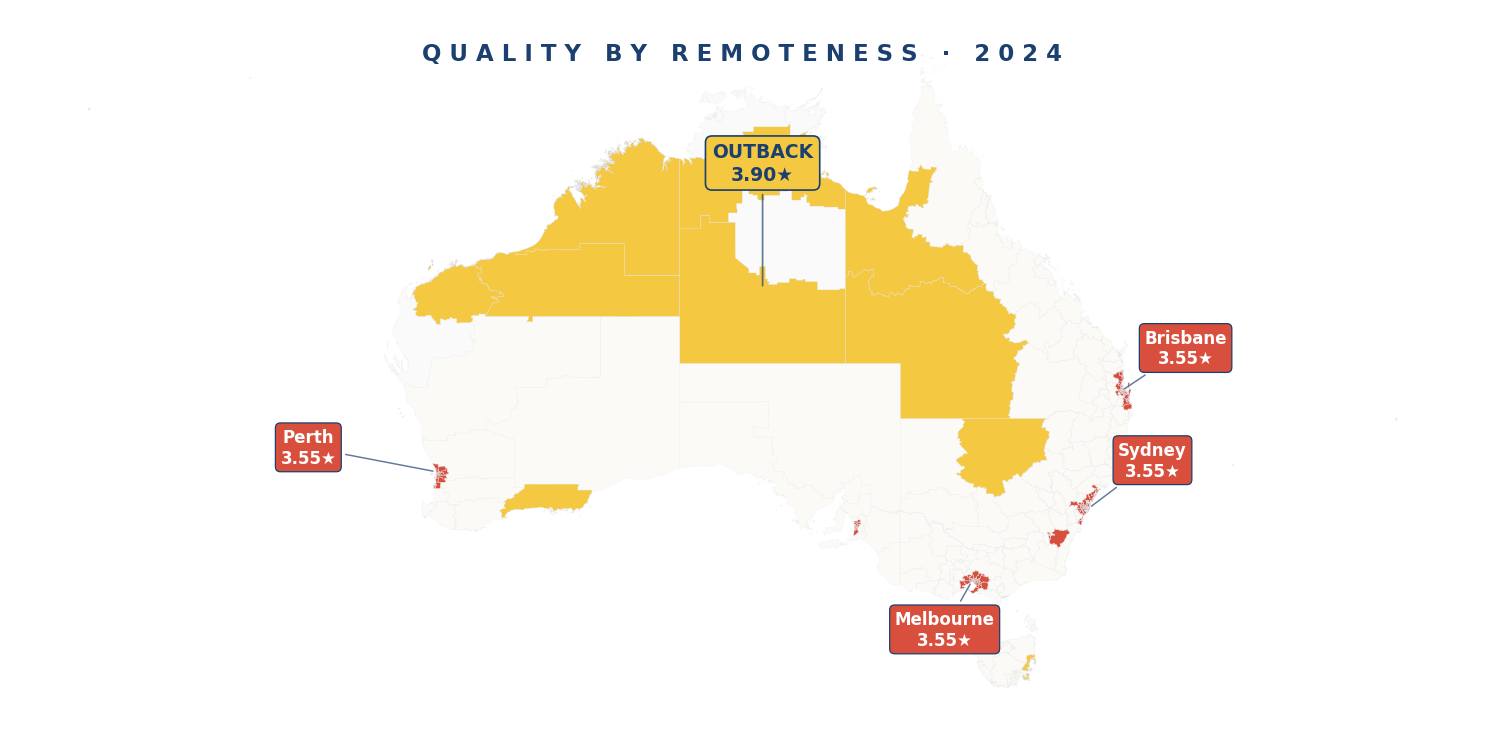

In [115]:
# Defensive dtype guard
gdf["SA3_CODE21"] = pd.to_numeric(gdf["SA3_CODE21"], errors="coerce").astype("Int64")
ratings["sa3_code"] = pd.to_numeric(ratings["sa3_code"], errors="coerce").astype("Int64")

# Build SA3 → MMM mapping from ratings
mmm_sa3 = (
    ratings.dropna(subset=["sa3_code", "mmm_code"])
    .groupby("sa3_code")["mmm_code"]
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None)
    .reset_index()
)
mmm_sa3["mmm_num"] = (
    mmm_sa3["mmm_code"].str.extract(r"(\d)", expand=False).astype(float)
)
mmm_sa3["sa3_code"] = mmm_sa3["sa3_code"].astype("Int64")

# Merge to shapefile
gdf_s3 = gdf.merge(
    mmm_sa3[["sa3_code", "mmm_num"]],
    left_on="SA3_CODE21", right_on="sa3_code", how="left"
)

# ============================================================
# EDITORIAL STYLE — solid white background
# Gold = MM6/7 remote (high quality)
# Red  = MM1 major cities (low quality)
# Very faint cream = MM2-5 (almost invisible — gold & red carry the message)
# No legend at bottom — the OUTBACK and city pills are self-explanatory
# ============================================================

WHITE_BG    = "#FFFFFF"
GOLD_FILL   = PALETTE["gold"]      # #F5C842 — outback / MM6/7
RED_FILL    = PALETTE["red"]       # #D94F3D — major cities / MM1
NEUTRAL     = "#FAF5EC"            # very faint cream for MM2-5 (almost invisible)
NO_DATA     = "#F8F8F8"            # near-white missing data
NAVY_INK    = PALETTE["navy"]
HAIRLINE    = "#E0E3E8"            # very thin, light grey

def _mmm_color(mmm_num):
    if pd.isna(mmm_num):
        return NO_DATA
    if mmm_num >= 6:
        return GOLD_FILL
    elif mmm_num == 1:
        return RED_FILL
    else:
        return NEUTRAL

gdf_s3["fill_color"] = gdf_s3["mmm_num"].apply(_mmm_color)

# Chart with white background
fig, ax = plt.subplots(figsize=(9.6, 5.4), facecolor=WHITE_BG)
ax.set_facecolor(WHITE_BG)

# Layer order: neutral (very faint) first, then gold, then red on top
for color, alpha in [(NEUTRAL, 0.45), (GOLD_FILL, 1.0), (RED_FILL, 1.0)]:
    subset = gdf_s3[gdf_s3["fill_color"] == color]
    if not subset.empty:
        subset.plot(ax=ax, facecolor=color, edgecolor=HAIRLINE,
                    linewidth=0.15, alpha=alpha)

# No-data zones
gdf_s3[gdf_s3["fill_color"] == NO_DATA].plot(
    ax=ax, facecolor=NO_DATA, edgecolor=HAIRLINE, linewidth=0.12, alpha=0.6
)

# ----- Editorial title at top (letter-spaced manually) -----
ax.text(
    0.5, 0.97, "Q U A L I T Y   B Y   R E M O T E N E S S   ·   2 0 2 4",
    transform=ax.transAxes, ha="center", va="top",
    fontsize=11, color=NAVY_INK, fontweight="bold",
    family="DejaVu Sans",
)

# ----- City labels (red pills with white text) -----
cities = [
    ("Sydney\n3.55★",    151.2, -33.9,  3.5,  1.8),
    ("Melbourne\n3.55★", 144.9, -37.8, -1.5, -3.5),
    ("Brisbane\n3.55★",  153.0, -27.5,  3.5,  1.5),
    ("Perth\n3.55★",     115.8, -31.9, -7.0,  0.5),
]
for label, lon, lat, dx, dy in cities:
    ax.annotate(
        label,
        xy=(lon, lat),
        xytext=(lon + dx, lat + dy),
        fontsize=8, fontweight="bold", color="white", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=RED_FILL,
                  edgecolor=NAVY_INK, linewidth=0.6),
        arrowprops=dict(arrowstyle="-", color=NAVY_INK, lw=0.7, alpha=0.7),
    )

# ----- OUTBACK callout (gold pill, navy text) -----
ax.annotate(
    "OUTBACK\n3.90★",
    xy=(133.5, -22.0),
    xytext=(133.5, -16.0),
    fontsize=9, fontweight="bold", color=NAVY_INK, ha="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor=GOLD_FILL,
              edgecolor=NAVY_INK, linewidth=0.8),
    arrowprops=dict(arrowstyle="-", color=NAVY_INK, lw=0.8, alpha=0.7),
)

ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout(pad=0)
export_png(fig, "S3_australia_silhouette")
plt.show()

---
## S4 — Choropleth: Care Gap Index 2024 (Map slide)

**WHY this chart for S4:**  
S4 pays off the S3 hook with a precise quantitative map. The silhouette showed *which* areas are in crisis; this choropleth shows *how bad* each SA3 is. Unley's 2.78 Care Gap Index must be visible and annotated — it is the anchor number the speaker names first.

**MUST show:**
- Care Gap Index by SA3, 2024, using a Red → Light colour ramp (high = red/urgent)
- Unley (SA) annotated with value 2.78
- Legend (care gap scale)
- Continent-only crop, no ocean labels

**MUST NOT:**
- SA3 border lines heavy (use 0.1 linewidth — they clutter the map at this zoom)
- State labels (too much text for a 30s slide read)
- Streamlit chrome (this is a clean export)

**Source:** `master_sa3.csv` (2024, `care_gap_index`) + SA3 shapefile

  ✓  S4_choropleth_caregap_2024.png  (184 kb)


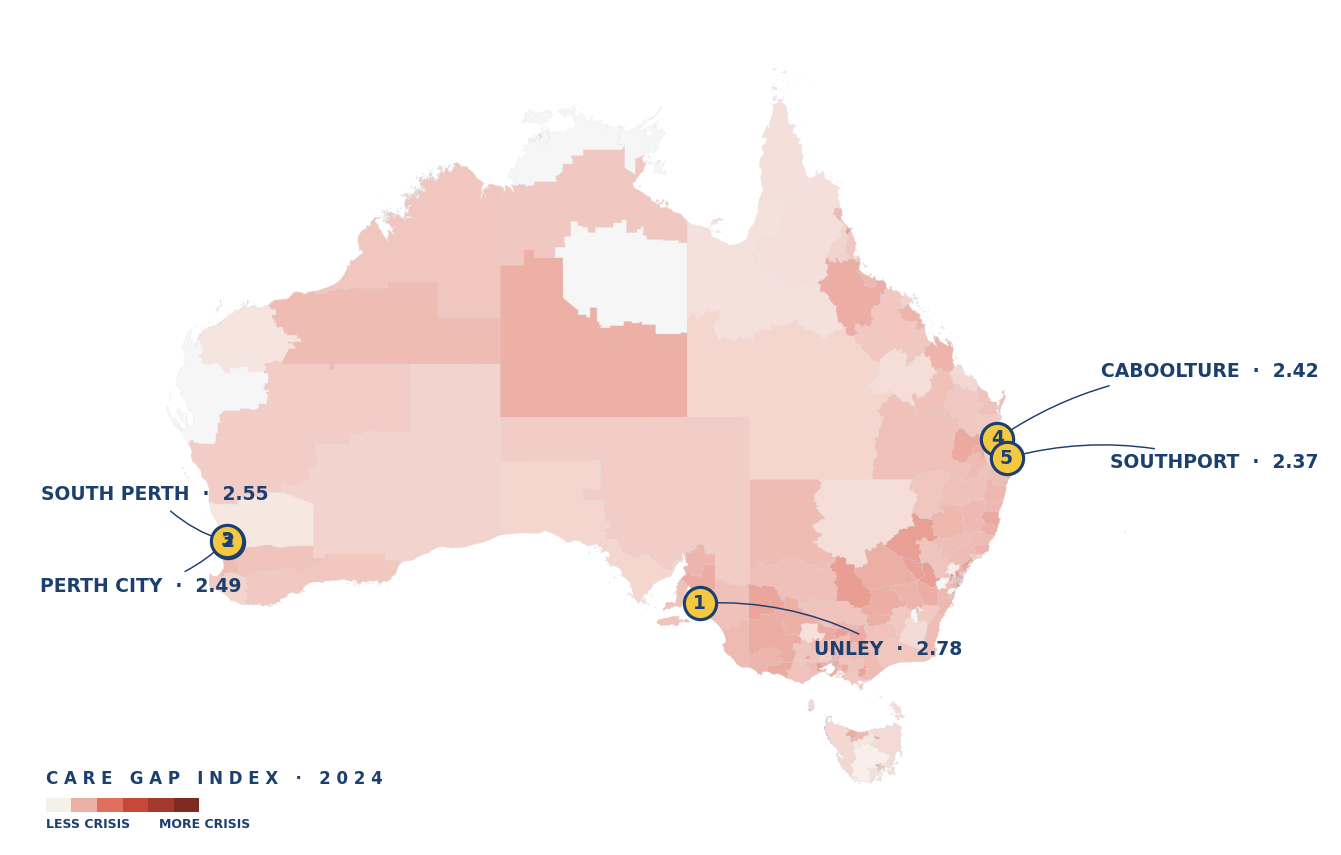

In [116]:
# Defensive dtype guard
gdf["SA3_CODE21"] = pd.to_numeric(gdf["SA3_CODE21"], errors="coerce").astype("Int64")
master["sa3_code"] = pd.to_numeric(master["sa3_code"], errors="coerce").astype("Int64")

master_2024 = master[master["year"] == 2024].copy()

gdf_s4 = gdf.merge(
    master_2024[["sa3_code", "care_gap_index", "sa3_name"]],
    left_on="SA3_CODE21", right_on="sa3_code", how="left"
)

# ============================================================
# EDITORIAL STYLE — white bg, faint mono red ramp, 5 named pins on top
# Pins: top-5 worst SA3 (Unley, South Perth, Perth City, Caboolture, Southport)
# Labels arranged in the ocean around the continent so they don't overlap data
# ============================================================

WHITE_BG     = "#FFFFFF"
PALE_FILL    = "#F5F0E8"
MID_RED      = PALETTE["red"]
DEEP_RED     = "#7E2A20"
NAVY_INK     = PALETTE["navy"]
GOLD_PIN     = PALETTE["gold"]
HAIRLINE     = "#D6DCE3"
NO_DATA_GREY = "#EFEFEF"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "caregap_editorial",
    [PALE_FILL, MID_RED, DEEP_RED],
    N=256,
)

fig, ax = plt.subplots(figsize=(9.6, 5.4), facecolor=WHITE_BG)
ax.set_facecolor(WHITE_BG)

# Faint choropleth — geographic context, alpha 0.55 so pins dominate
gdf_s4.plot(
    ax=ax,
    column="care_gap_index",
    cmap=cmap,
    vmin=0, vmax=3.0,
    missing_kwds={"color": NO_DATA_GREY, "edgecolor": HAIRLINE, "linewidth": 0.12},
    legend=False,
    edgecolor=HAIRLINE,
    linewidth=0.12,
    alpha=0.55,
)

# ----- Pin the 5 worst SA3 (with manual label offsets so they don't overlap) -----
# Format: (sa3_name_lookup, display_label, rank, care_gap, dx_offset, dy_offset)
top_sa3 = [
    ("Unley",        "UNLEY",        1, 2.78,   5.5, -2.5),   # Adelaide → label SE
    ("South Perth",  "SOUTH PERTH",  2, 2.55,  -9.0,  2.0),   # Perth   → label W (above)
    ("Perth City",   "PERTH CITY",   3, 2.49,  -9.0, -2.5),   # Perth   → label W (below)
    ("Caboolture",   "CABOOLTURE",   4, 2.42,   5.0,  3.0),   # Brisbane→ label NE
    ("Southport",    "SOUTHPORT",    5, 2.37,   5.0, -0.5),   # GoldCoast→ label E
]

for lookup, label, rank, gap, dx, dy in top_sa3:
    row = gdf_s4[gdf_s4["sa3_name"].str.contains(lookup, case=False, na=False)]
    if row.empty:
        print(f"  WARNING: SA3 '{lookup}' not found")
        continue
    cx = row.geometry.centroid.iloc[0].x
    cy = row.geometry.centroid.iloc[0].y

    # Gold pin with navy border + rank number inside
    ax.scatter([cx], [cy], s=240, color=GOLD_PIN, zorder=8,
               edgecolor=NAVY_INK, linewidth=1.5)
    ax.text(cx, cy, str(rank), color=NAVY_INK, fontsize=9, fontweight="bold",
            ha="center", va="center", zorder=9, family="DejaVu Sans")

    # Editorial label with thin connector
    ax.annotate(
        f"{label}  ·  {gap}",
        xy=(cx, cy),
        xytext=(cx + dx, cy + dy),
        fontsize=9, fontweight="bold", color=NAVY_INK,
        family="DejaVu Sans",
        arrowprops=dict(arrowstyle="-", color=NAVY_INK, lw=0.7,
                        connectionstyle="arc3,rad=0.15"),
        bbox=None,
    )

# Expand axes a bit so labels in ocean stay visible
ax.set_xlim(106, 162)
ax.set_ylim(-46, -7)

# ----- Bottom-left scale label + tiny mono ramp -----
ax.text(0.02, 0.06, "C A R E   G A P   I N D E X   ·   2 0 2 4",
        transform=ax.transAxes, fontsize=8, color=NAVY_INK,
        family="DejaVu Sans", fontweight="bold")

n_swatches = 6
swatch_w   = 0.022
for i in range(n_swatches):
    t = i / (n_swatches - 1)
    color = cmap(t)
    rect_patch = plt.Rectangle(
        (0.02 + i * swatch_w, 0.025), swatch_w, 0.018,
        transform=ax.transAxes, facecolor=color, edgecolor="none"
    )
    ax.add_patch(rect_patch)

ax.text(0.02, 0.005, "LESS CRISIS", transform=ax.transAxes,
        fontsize=6, color=NAVY_INK, family="DejaVu Sans", fontweight="bold")
ax.text(0.02 + n_swatches * swatch_w - 0.035, 0.005, "MORE CRISIS",
        transform=ax.transAxes, fontsize=6, color=NAVY_INK,
        family="DejaVu Sans", fontweight="bold")

ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout(pad=0)
export_png(fig, "S4_choropleth_caregap_2024")
plt.show()

---
## S5 — Ownership Quality Trend (12 quarters, Correlation slide)

**WHY this chart for S5:**  
The headline claim is "the 0.57-star gap has not moved in 12 quarters." A time-series line chart is the only visual that proves *stability* rather than a one-point snapshot. Three flat, parallel lines make the argument viscerally: there is no trend, no convergence, no improvement.

**MUST show:**
- Three lines: Government (teal), Not-for-profit (blue-mid), For-profit (red)
- October 2023 mandate vline in gold with label
- Y-axis starting around 3.2 (not 0 — to show the gap, not the scale)
- At least 10 distinct quarterly snapshots (May 2023 → Feb 2026)

**MUST NOT:**
- Confidence intervals / error bands (distract from the flat-gap story)
- Individual facility scatter (noise)
- Y-axis from 0 (makes the gap look tiny)

**Source:** `star_ratings_by_facility.csv` → Purpose → org_type → group by snapshot_date × org_type → mean quality_score

  ✓  S5_ownership_trend_12q.png  (97 kb)


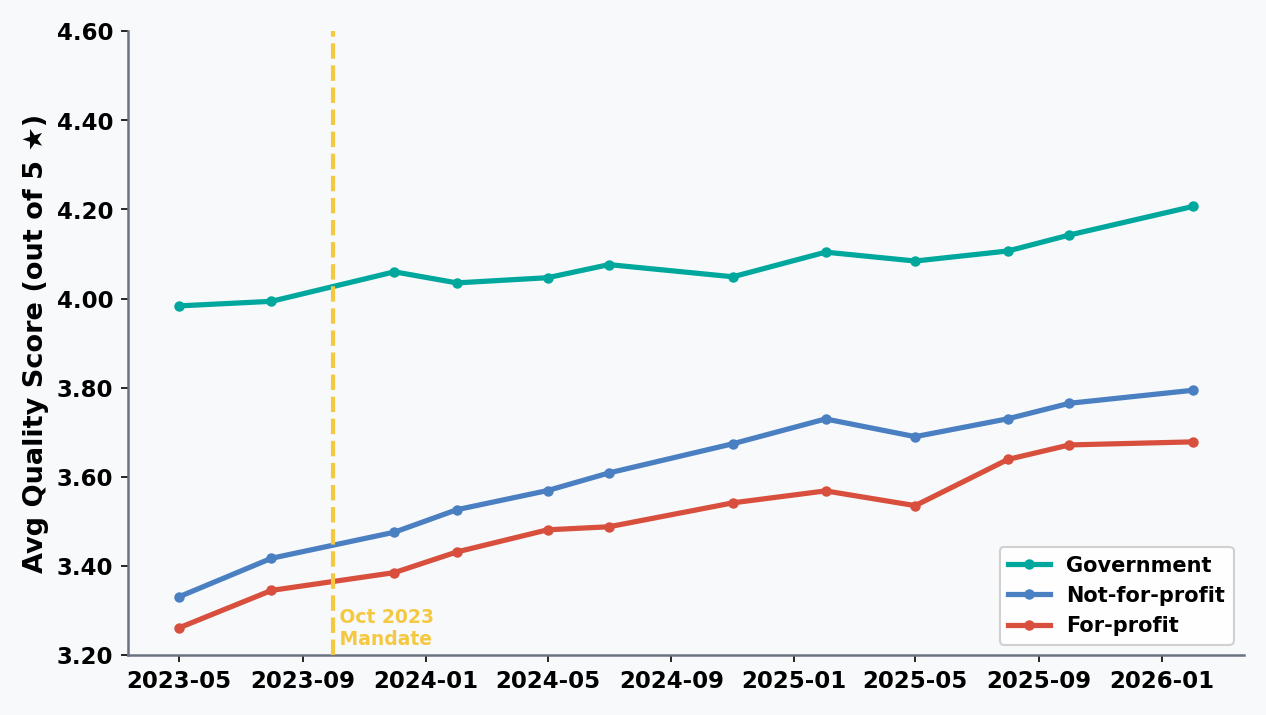


Endpoint quality scores (latest snapshot):
      org_type  quality_score
not_for_profit       3.794114
    government       4.206880
        profit       3.678246


In [117]:
trend = (
    ratings.dropna(subset=["org_type", "quality_score", "snapshot_date"])
    .groupby(["snapshot_date", "org_type"])["quality_score"]
    .mean()
    .reset_index()
    .sort_values("snapshot_date")
)

fig, ax = plt.subplots(facecolor=PALETTE["grey_bg"])
ax.set_facecolor(PALETTE["grey_bg"])

for org_key in ["government", "not_for_profit", "profit"]:
    d = trend[trend["org_type"] == org_key]
    if d.empty:
        print(f"  WARNING: no data for org_type='{org_key}'")
        continue
    ax.plot(
        d["snapshot_date"], d["quality_score"],
        color=ORG_COLORS[org_key], lw=2.5, marker="o", ms=4,
        label=ORG_LABELS[org_key]
    )

# Mandate vline
mandate_ts = pd.Timestamp("2023-10-01")
ax.axvline(mandate_ts, color=PALETTE["gold"], lw=2.0, ls="--", zorder=5)
ax.text(
    mandate_ts, ax.get_ylim()[0] if ax.get_ylim()[0] > 3.0 else 3.25,
    " Oct 2023\n Mandate",
    color=PALETTE["gold"], fontsize=9, va="bottom"
)

ax.set_ylim(3.2, 4.6)
ax.set_ylabel("Avg Quality Score (out of 5 ★)")
ax.set_xlabel("")
ax.legend(loc="lower right", framealpha=0.9, fontsize=10)
ax.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%.2f"))

export_png(fig, "S5_ownership_trend_12q")
plt.show()

# Print endpoint values for audit
last_snap = trend["snapshot_date"].max()
print("\nEndpoint quality scores (latest snapshot):")
print(trend[trend["snapshot_date"] == last_snap][["org_type", "quality_score"]].to_string(index=False))

---
## S6 — Funding vs Quality Scatter (Funding Paradox slide)

**WHY this chart for S6:**  
The claim "2.6× more public money goes to the worst-quality type" is explosive. A scatter with 3 large bubbles (one per org type) — where the X-axis is funding, Y-axis is quality, and bubble size is number of facilities — makes the paradox immediate: the big-funded bubble is at the bottom-right corner.

**MUST show:**
- 3 bubbles only (Government teal, NFP blue-mid, For-profit red)
- X-axis: average government funding per facility ($M)
- Y-axis: average quality score (★)
- Bubble size: proportional to number of facilities (so the audience sees scale)
- Axis labels clear enough to read during the pitch (font 12+)

**MUST NOT:**
- A trendline (the story is the *gap*, not the correlation slope)
- Per-SA3 scatter dots (too many points, loses the 3-group message)
- Log scale on X (the 2.6× ratio must be visually obvious on a linear scale)

**Source:** `service_funding_by_facility.csv` (avg funding/facility by org_type) joined with `star_ratings_by_facility.csv` (avg quality by org_type)

S6 data:
      org_type  avg_funding_M  avg_quality  n_facilities
    government       3.169902     4.070780           599
not_for_profit       6.376355     3.609196          3124
        profit       8.125636     3.498143          1565
  ✓  S6_funding_quality_scatter.png  (81 kb)


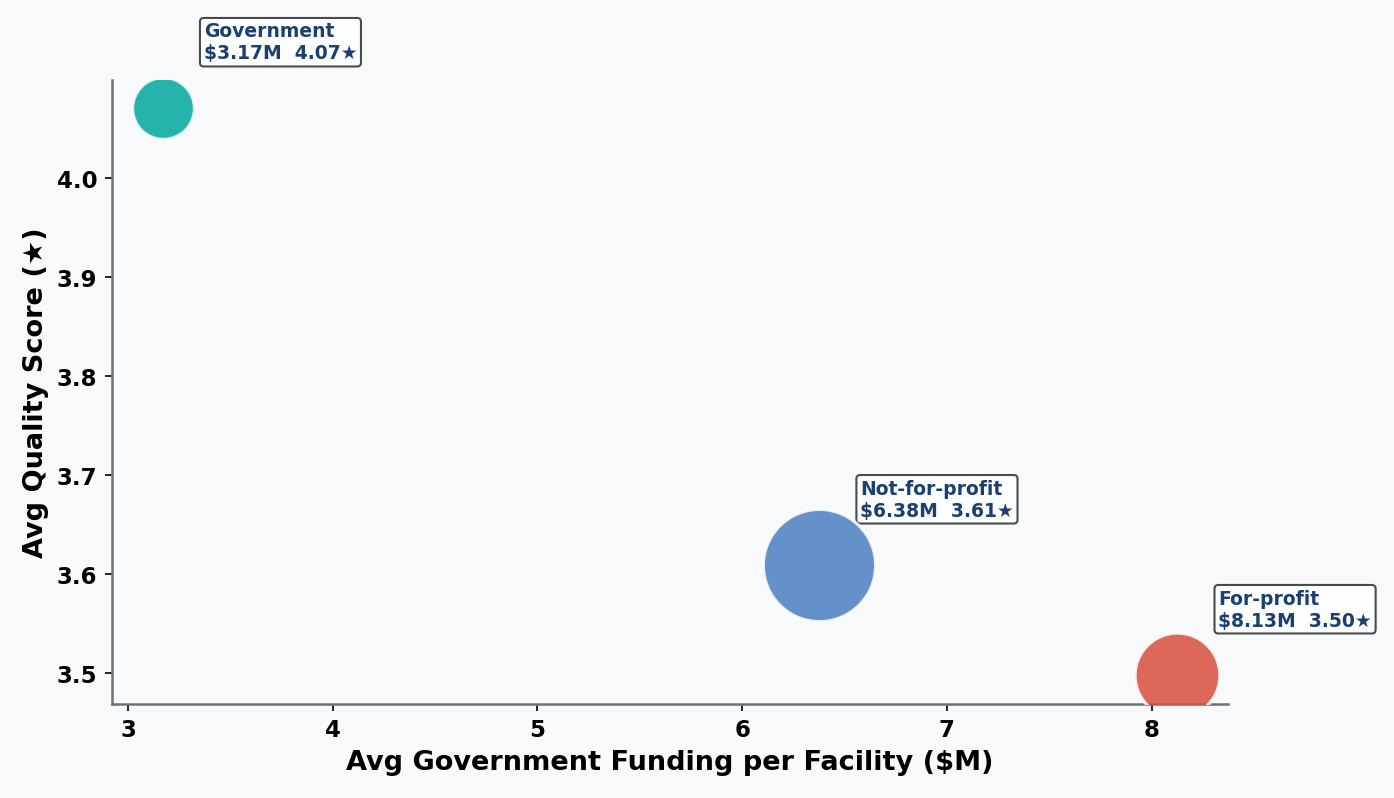

In [118]:
# Funding: avg per facility by org_type (latest year available)
latest_fund_year = funding["year"].max()
fund_agg = (
    funding[funding["year"] == latest_fund_year]
    .groupby("org_type")
    .agg(
        total_funding=("funding", "sum"),
        n_facilities=("funding", "count"),
    )
    .reset_index()
)
fund_agg["avg_funding_M"] = fund_agg["total_funding"] / fund_agg["n_facilities"] / 1e6

# Quality: avg by org_type across all snapshots
qual_agg = (
    ratings.dropna(subset=["org_type", "quality_score"])
    .groupby("org_type")["quality_score"]
    .mean()
    .reset_index()
    .rename(columns={"quality_score": "avg_quality"})
)

df_s6 = fund_agg.merge(qual_agg, on="org_type")
print("S6 data:")
print(df_s6[["org_type", "avg_funding_M", "avg_quality", "n_facilities"]].to_string(index=False))

# Chart
fig, ax = plt.subplots(facecolor=PALETTE["grey_bg"])
ax.set_facecolor(PALETTE["grey_bg"])

# Bubble size: scale n_facilities to ~200–2000 point² range
max_n = df_s6["n_facilities"].max()

for _, row in df_s6.iterrows():
    org = row["org_type"]
    color = ORG_COLORS.get(org, PALETTE["grey_axis"])
    label = ORG_LABELS.get(org, org)
    size = (row["n_facilities"] / max_n) * 2500 + 400
    ax.scatter(
        row["avg_funding_M"], row["avg_quality"],
        s=size, color=color, alpha=0.85, edgecolors="white",
        linewidth=1.5, zorder=5, label=label
    )
    # Label inside / above bubble
    ax.annotate(
        f"{label}\n${row['avg_funding_M']:.2f}M  {row['avg_quality']:.2f}★",
        xy=(row["avg_funding_M"], row["avg_quality"]),
        xytext=(row["avg_funding_M"] + 0.2, row["avg_quality"] + 0.05),
        fontsize=9, color=PALETTE["navy"], fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
    )

ax.set_xlabel("Avg Government Funding per Facility ($M)")
ax.set_ylabel("Avg Quality Score (★)")

export_png(fig, "S6_funding_quality_scatter")
plt.show()

---
## S7 — Top-10 Waitlist Pressure (Human Cost slide)

**WHY this chart for S7:**  
S7 is the Heart-String slide. Naming specific places makes the crisis human — not a national average, but a ranked list where the speaker can say "Central Highlands, Tasmania" out loud and point to the bar. The chart must be readable from the back row.

**MUST show:**
- Top-10 SA3s by waitlist_pressure, 2024 (high-needs HCP users per residential bed)
- Central Highlands TAS at the top of the chart (highest value)
- Red dashed crisis threshold at ratio = 1.0
- Value labels at end of each bar

**MUST NOT:**
- All 58 crisis zones (too crowded for a 30s slide)
- X-axis title "ratio" (the unit label on the axis is sufficient)
- Colour variation per bar (red for all → uniform urgency)

**Source:** `master_sa3.csv` (2024, `waitlist_pressure`) — pre-computed in the master

  ✓  S7_waitlist_top10_2024.png  (121 kb)


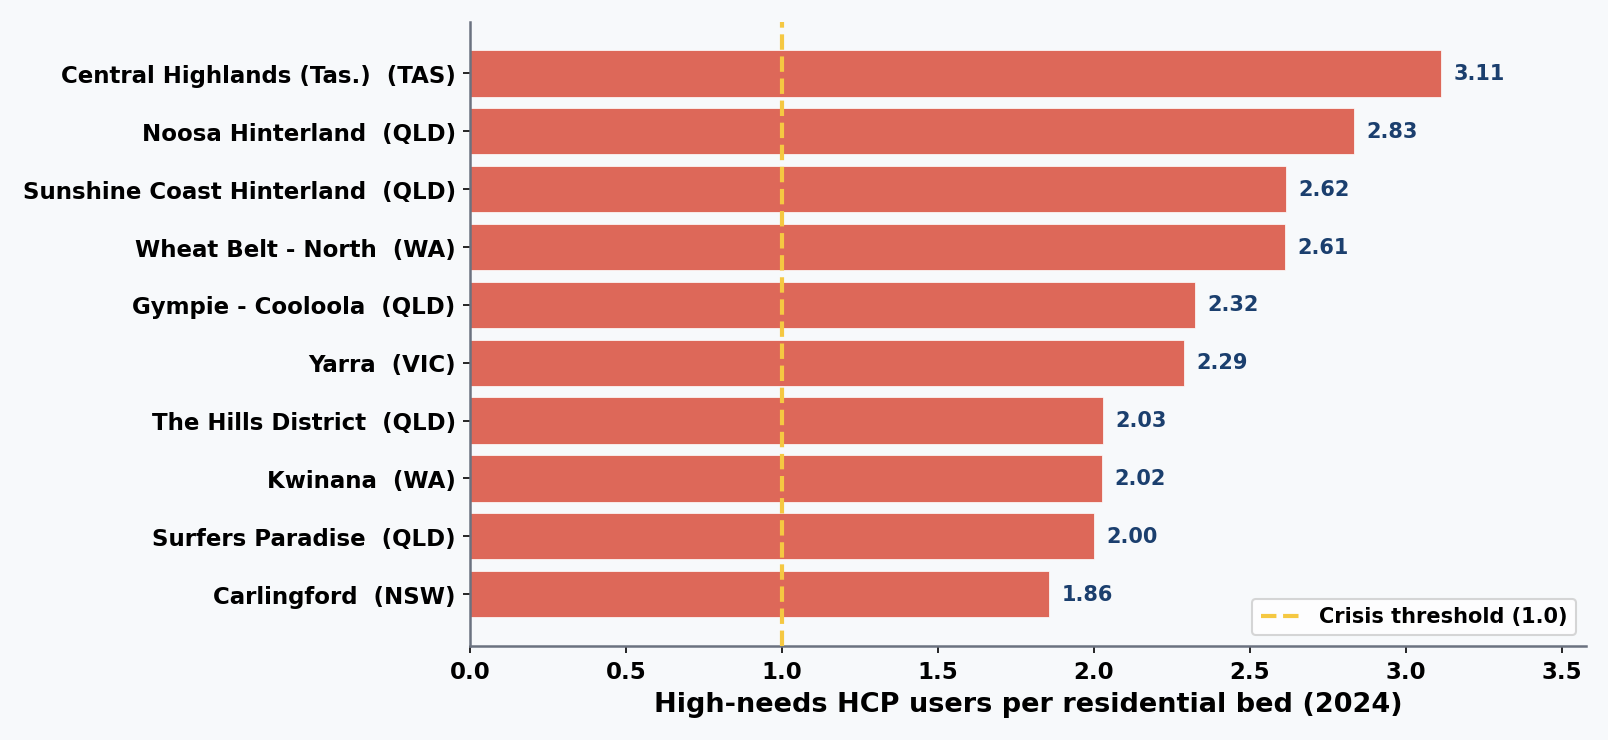

In [119]:
top10 = (
    master_2024.dropna(subset=["waitlist_pressure"])
    .nlargest(10, "waitlist_pressure")
    .sort_values("waitlist_pressure", ascending=True)   # ascending so highest is at top of hbar
    [["sa3_name", "state", "waitlist_pressure"]]
)
top10["label"] = top10["sa3_name"] + "  (" + top10["state"] + ")"

fig, ax = plt.subplots(facecolor=PALETTE["grey_bg"])
ax.set_facecolor(PALETTE["grey_bg"])

bars = ax.barh(
    top10["label"], top10["waitlist_pressure"],
    color=PALETTE["red"], alpha=0.85,
    edgecolor="white", linewidth=0.4
)

# Crisis threshold line
ax.axvline(1.0, color=PALETTE["gold"], lw=2.0, ls="--", zorder=6, label="Crisis threshold (1.0)")

# Value labels
for bar, val in zip(bars, top10["waitlist_pressure"]):
    ax.text(
        val + 0.04, bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center", fontsize=10, fontweight="bold", color=PALETTE["navy"]
    )

ax.set_xlabel("High-needs HCP users per residential bed (2024)")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, top10["waitlist_pressure"].max() * 1.15)

export_png(fig, "S7_waitlist_top10_2024")
plt.show()

---
## S8 — Supply Divergence Indexed 2019–2024 (Supply Failure slide)

**WHY this chart for S8:**  
The headline claim is "we are not building too few beds nationally — we are building them in the wrong places." An indexed line chart (both lines start at 100 in 2019) makes the divergence undeniable in 2 seconds. The gold-shaded gap between lines IS the argument.

**MUST show:**
- Two lines: "58 crisis zones" (red, trending down) and "Rest of Australia" (teal, trending up)
- Both indexed to 2019 = 100
- Gold-shaded area between the two lines (labelled "supply divergence")
- Year labels on X-axis

**MUST NOT:**
- Raw bed counts (the *index* is what makes the 2.6× gap legible)
- Facility count overlay (a separate story — don't mix metrics)
- Lines starting from 0 (makes the divergence look tiny)

**Source:** `master_sa3.csv` → identify crisis SA3s (waitlist_pressure > 1.0 in 2024), then `service_supply_by_sa3.csv` grouped by year × crisis/rest → sum residential_places → index

Crisis SA3s (pressure > 1.0): 58
  ✓  S8_supply_divergence_indexed.png  (95 kb)


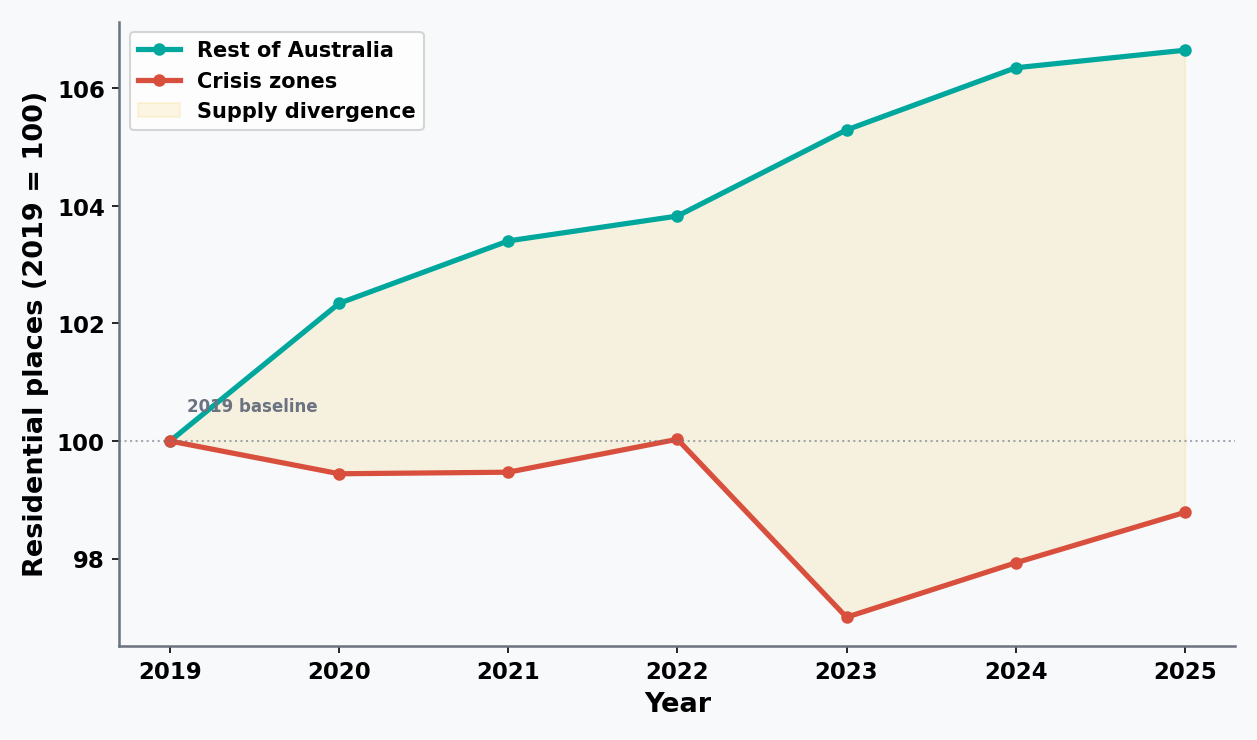


2024 indexed values:
            group  residential_places    indexed
     Crisis zones             26036.0  97.927559
Rest of Australia            201429.0 106.349986


In [120]:
# Defensive dtype guard
master["sa3_code"]  = pd.to_numeric(master["sa3_code"],  errors="coerce").astype("Int64")
supply["sa3_code"]  = pd.to_numeric(supply["sa3_code"],  errors="coerce").astype("Int64")
master_2024 = master[master["year"] == 2024].copy()

# Identify crisis SA3s from master 2024
crisis_codes = set(
    master_2024.loc[master_2024["waitlist_pressure"] > 1.0, "sa3_code"].dropna().astype(int).tolist()
)
print(f"Crisis SA3s (pressure > 1.0): {len(crisis_codes)}")

# Tag supply rows
supply_tagged = supply.dropna(subset=["sa3_code"]).copy()
supply_tagged["group"] = supply_tagged["sa3_code"].apply(
    lambda x: "Crisis zones" if int(x) in crisis_codes else "Rest of Australia"
)

# Aggregate and index
grp_yr = (
    supply_tagged.groupby(["year", "group"])["residential_places"]
    .sum().reset_index()
)
base_2019 = grp_yr[grp_yr["year"] == 2019].set_index("group")["residential_places"]
grp_yr["indexed"] = grp_yr.apply(
    lambda r: (r["residential_places"] / base_2019[r["group"]]) * 100
    if r["group"] in base_2019.index else None,
    axis=1
)

fig, ax = plt.subplots(facecolor=PALETTE["grey_bg"])
ax.set_facecolor(PALETTE["grey_bg"])

grp_spec = {
    "Rest of Australia": PALETTE["teal"],
    "Crisis zones":      PALETTE["red"],
}
plotted = {}
for group, color in grp_spec.items():
    d = grp_yr[grp_yr["group"] == group].sort_values("year")
    line, = ax.plot(d["year"], d["indexed"], color=color, lw=2.5,
                    marker="o", ms=5, label=group)
    plotted[group] = d

# Gold gap fill
if len(plotted) == 2:
    rest   = plotted["Rest of Australia"]
    crisis = plotted["Crisis zones"]
    common_years = sorted(set(rest["year"]).intersection(crisis["year"]))
    r_vals = rest.set_index("year").loc[common_years, "indexed"]
    c_vals = crisis.set_index("year").loc[common_years, "indexed"]
    ax.fill_between(common_years, c_vals, r_vals,
                    alpha=0.15, color=PALETTE["gold"], label="Supply divergence")

# Baseline
ax.axhline(100, color=PALETTE["grey_axis"], lw=1.0, ls=":", alpha=0.6)
ax.text(grp_yr["year"].min() + 0.1, 100.5, "2019 baseline",
        fontsize=8, color=PALETTE["grey_axis"])

ax.set_xlabel("Year")
ax.set_ylabel("Residential places (2019 = 100)")
ax.legend(fontsize=10)
ax.set_xticks(sorted(grp_yr["year"].unique()))

export_png(fig, "S8_supply_divergence_indexed")
plt.show()

# Print 2024 endpoint values for plan audit
print("\n2024 indexed values:")
print(grp_yr[grp_yr["year"] == 2024][["group", "residential_places", "indexed"]].to_string(index=False))

---
## S11 — National Quality Timeline (Verdict slide)

**WHY this chart for S11:**  
S11 is the closing slide. It needs to show the mandate effect clearly (the step-change in quality after Oct 2023) but also set up the "better on paper, not in lives" message. The national avg quality line is the only chart that shows both the improvement (+0.25★) AND its limitations (outcomes flat). This is the chart that earns the CTA.

**MUST show:**
- National average quality score across all 12 quarterly snapshots
- Gold vertical line at Oct 2023 with label
- The post-mandate step-change (+0.25★) is visually obvious
- Y-axis cropped to show the gap clearly (start ≈ 3.2, not 0)

**MUST NOT:**
- Per-state lines (that's the Ch4 in-depth view — on this closing slide it's noise)
- Confidence bands (distracts from the clean step-change story)
- Sub-rating lines (quality_score is the single headline number here)

**Source:** `star_ratings_by_facility.csv` → group by snapshot_date → mean quality_score

  Pre-mandate last value:  3.441
  Post-mandate last value: 3.785
  Delta: +0.344★
  ✓  S11_quality_timeline_oct2023.png  (76 kb)


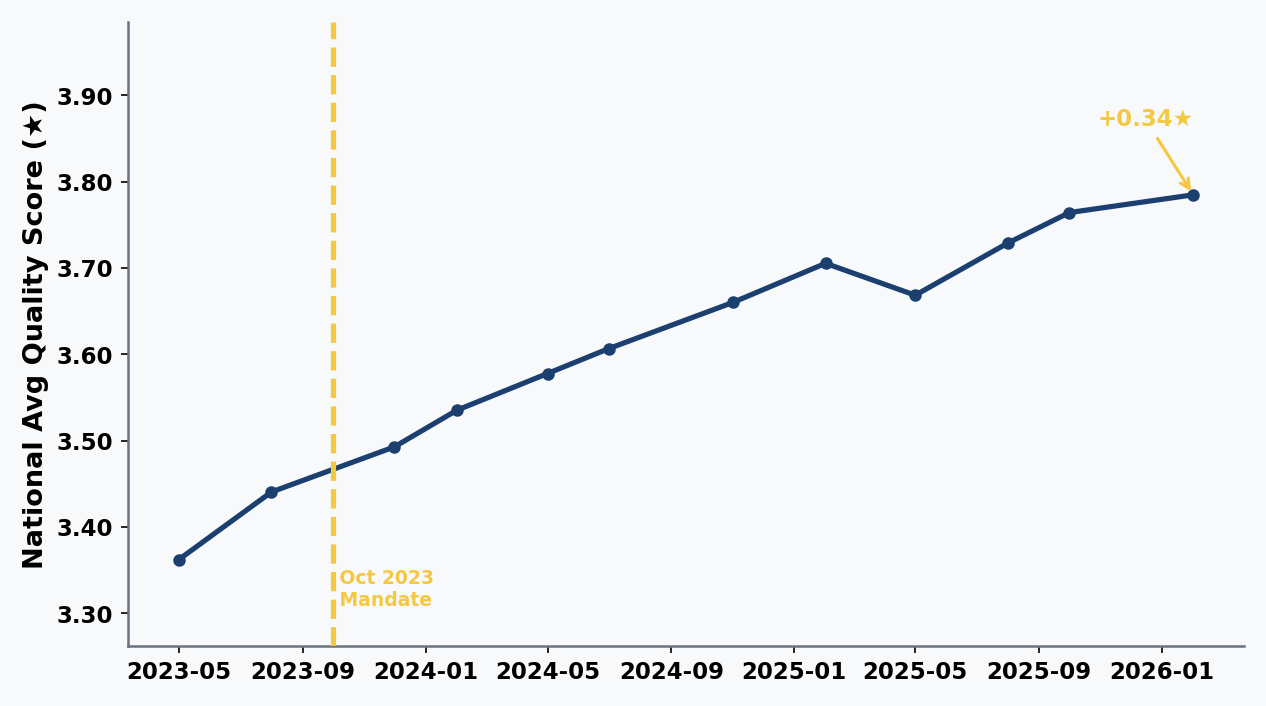

In [121]:
nat_trend = (
    ratings.dropna(subset=["quality_score", "snapshot_date"])
    .groupby("snapshot_date")["quality_score"]
    .mean()
    .reset_index()
    .sort_values("snapshot_date")
)

fig, ax = plt.subplots(facecolor=PALETTE["grey_bg"])
ax.set_facecolor(PALETTE["grey_bg"])

ax.plot(
    nat_trend["snapshot_date"], nat_trend["quality_score"],
    color=PALETTE["navy"], lw=2.5, marker="o", ms=5, zorder=5
)

# Mandate vline
mandate_ts = pd.Timestamp("2023-10-01")
ax.axvline(mandate_ts, color=PALETTE["gold"], lw=2.5, ls="--", zorder=6)
ax.text(
    mandate_ts, nat_trend["quality_score"].min() - 0.01,
    " Oct 2023\n Mandate",
    color=PALETTE["gold"], fontsize=9, va="top"
)

# Shade post-mandate region
post_mask = nat_trend["snapshot_date"] >= mandate_ts
if post_mask.any():
    pre_last  = nat_trend[~post_mask].iloc[-1]["quality_score"]
    post_last = nat_trend[post_mask].iloc[-1]["quality_score"]
    delta = post_last - pre_last

    # +0.25★ annotation on the last post-mandate point
    last_row = nat_trend[post_mask].iloc[-1]
    ax.annotate(
        f"+{delta:.2f}★",
        xy=(last_row["snapshot_date"], last_row["quality_score"]),
        xytext=(last_row["snapshot_date"], last_row["quality_score"] + 0.08),
        color=PALETTE["gold"], fontsize=11, fontweight="bold", ha="right",
        arrowprops=dict(arrowstyle="->", color=PALETTE["gold"], lw=1.5),
    )
    print(f"  Pre-mandate last value:  {pre_last:.3f}")
    print(f"  Post-mandate last value: {post_last:.3f}")
    print(f"  Delta: {delta:+.3f}★")

ax.set_ylim(nat_trend["quality_score"].min() - 0.1, nat_trend["quality_score"].max() + 0.2)
ax.set_ylabel("National Avg Quality Score (★)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%.2f"))

export_png(fig, "S11_quality_timeline_oct2023")
plt.show()

---
## Verification — Thumbnail Grid

Displays all exported PNGs side-by-side. Eyeball-check:
1. **Palette discipline** — only Navy / Teal / Gold / Red / Blue-lite / greys. No default matplotlib orange or blue.
2. **Crop** — no stray whitespace, no Streamlit chrome.
3. **File size** — each PNG printed above; anything > 3 MB may need DPI reduction.

If a chart fails the palette check, fix the code cell above and re-run only that cell + this one.

Found 7 chart PNGs in c:\Users\phamm\OneDrive\Documents\GitHub\dvn-at3-aged-care-gap\slides_deck\assets:
  S11_quality_timeline_oct2023.png  (76 kb)
  S3_australia_silhouette.png  (158 kb)
  S4_choropleth_caregap_2024.png  (184 kb)
  S5_ownership_trend_12q.png  (97 kb)
  S6_funding_quality_scatter.png  (81 kb)
  S7_waitlist_top10_2024.png  (121 kb)
  S8_supply_divergence_indexed.png  (95 kb)

✓ Thumbnail grid saved → _thumbnail_grid.png


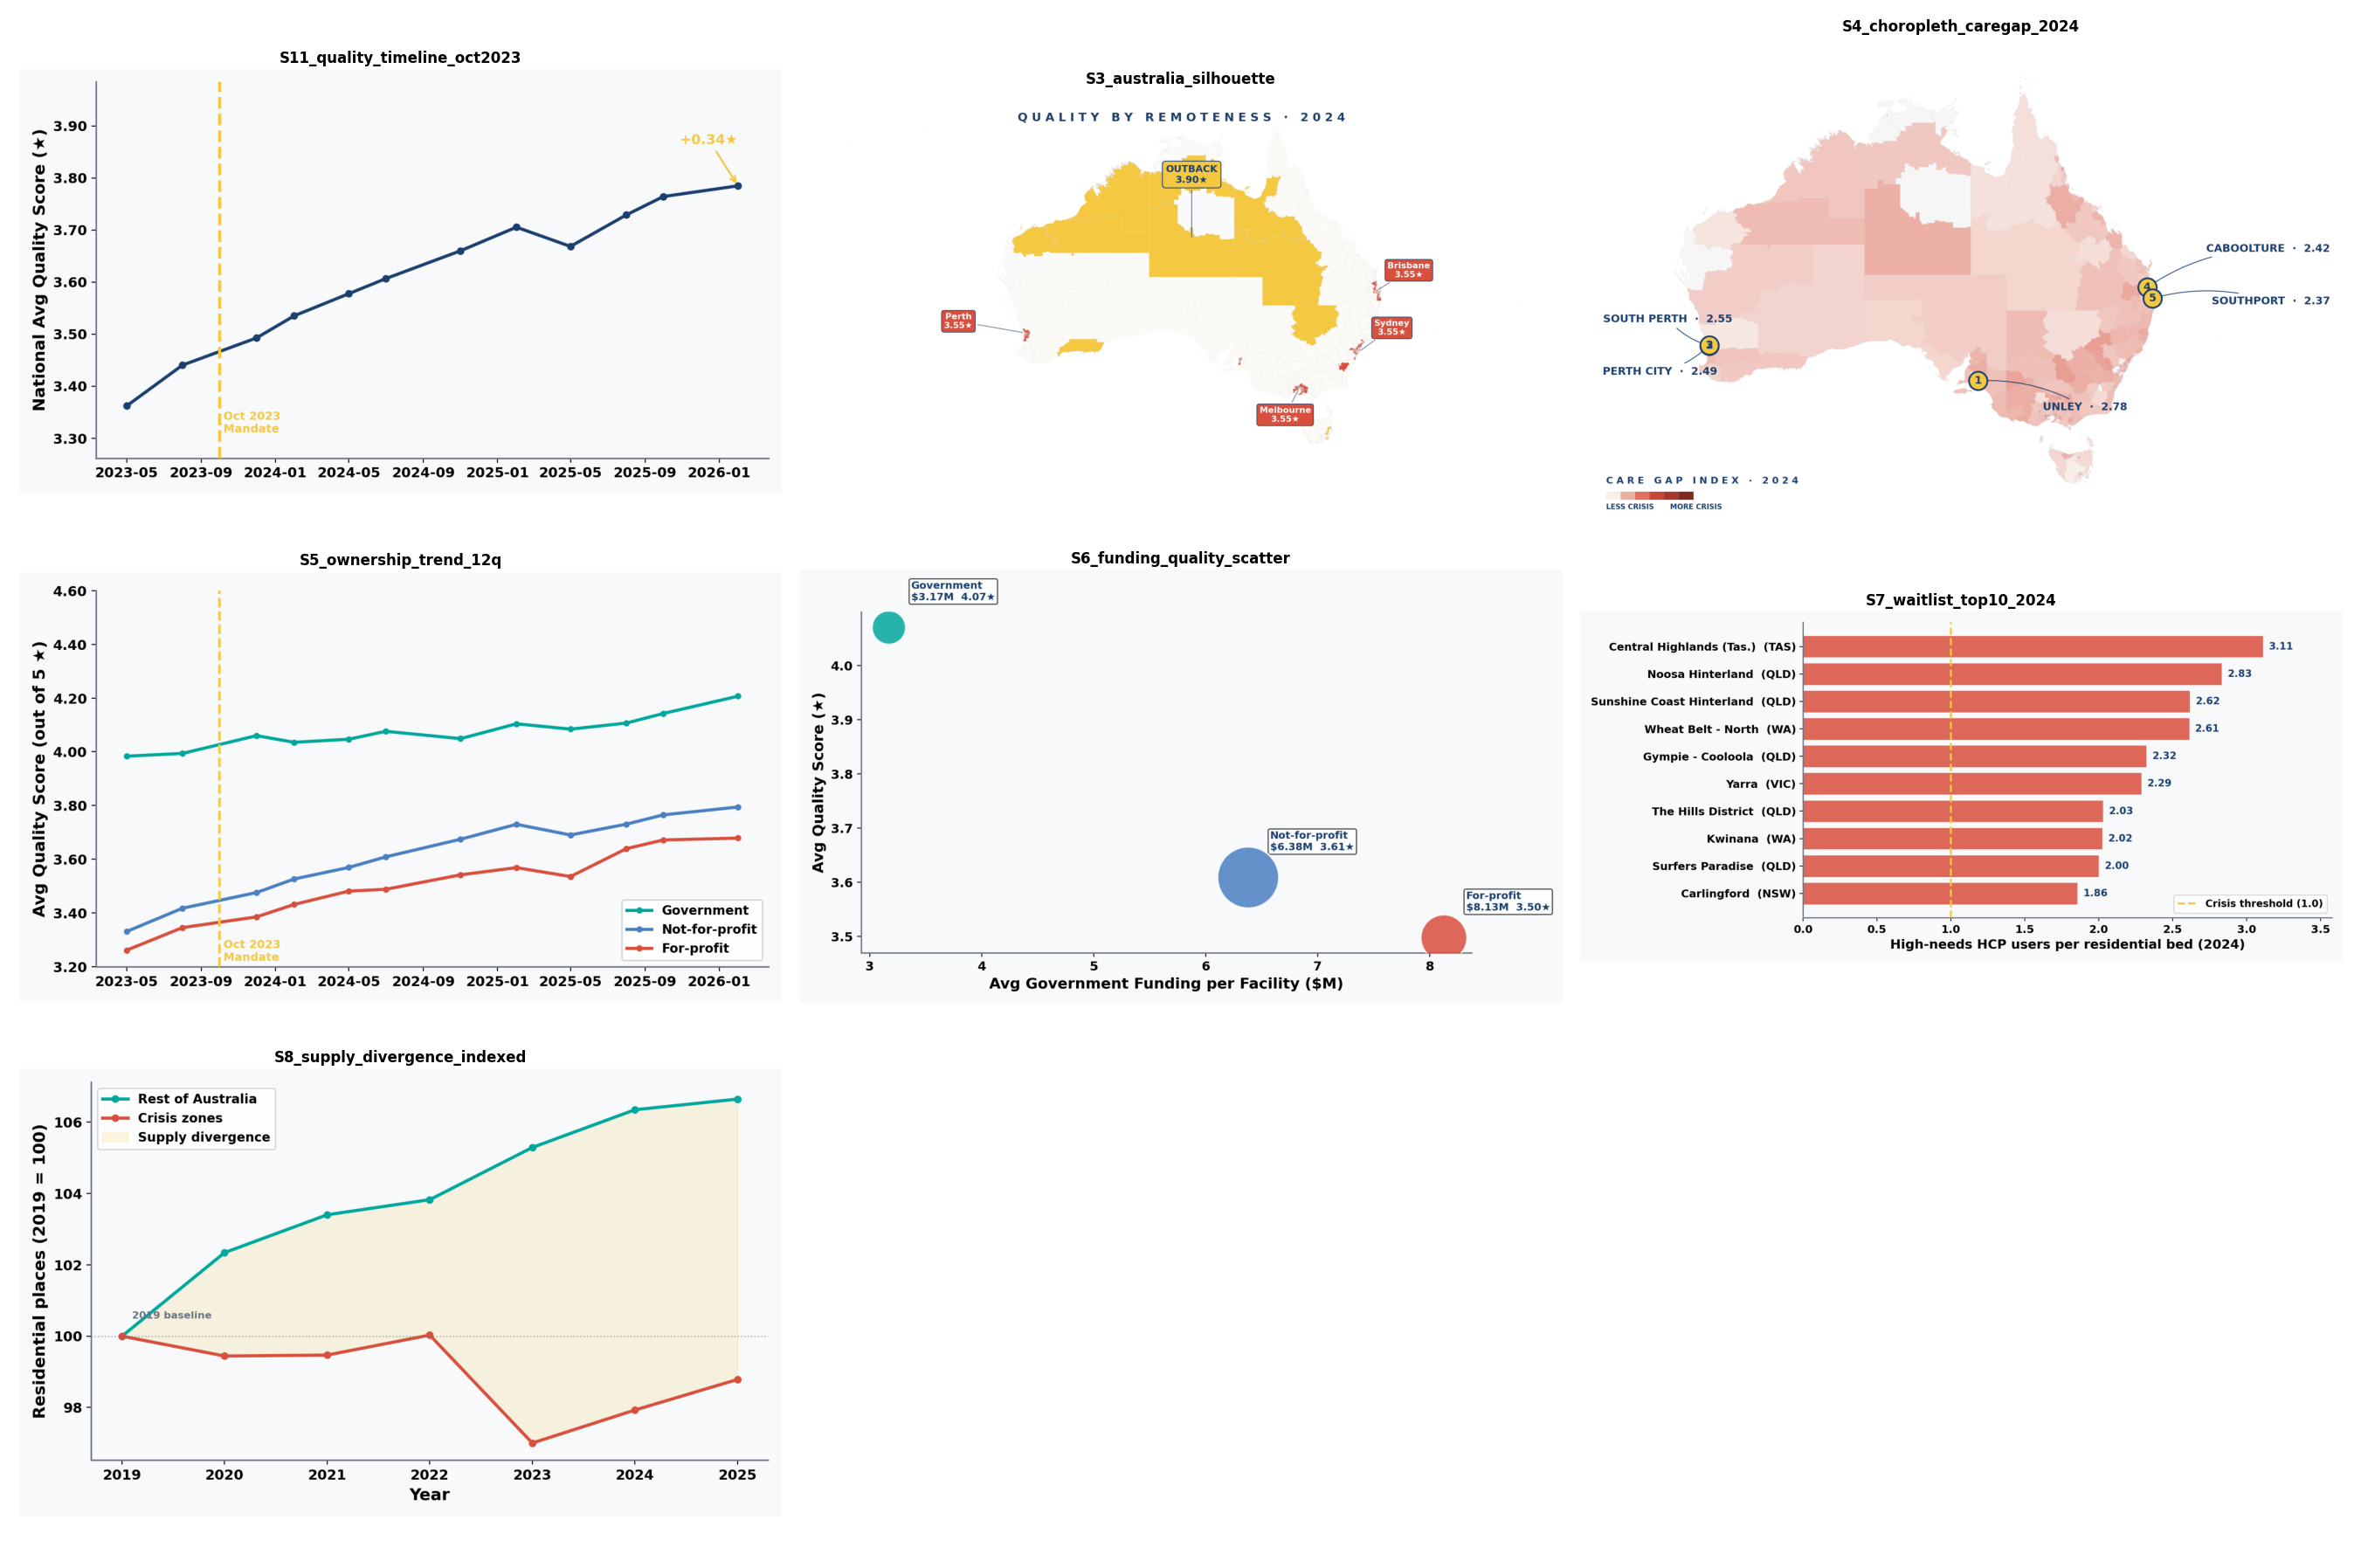

In [122]:
from PIL import Image as PilImage

pngs = sorted(OUTPUT_DIR.glob("S*.png"))
print(f"Found {len(pngs)} chart PNGs in {OUTPUT_DIR}:")
for p in pngs:
    print(f"  {p.name}  ({p.stat().st_size // 1024} kb)")

if pngs:
    n_cols = 3
    n_rows = (len(pngs) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), facecolor="white")
    axes = np.array(axes).flatten()

    for ax, png in zip(axes, pngs):
        img = PilImage.open(png)
        ax.imshow(img)
        ax.set_title(png.stem, fontsize=8, pad=4)
        ax.axis("off")

    for ax in axes[len(pngs):]:
        ax.axis("off")

    plt.tight_layout(pad=1.0)
    grid_path = OUTPUT_DIR / "_thumbnail_grid.png"
    plt.savefig(grid_path, dpi=80, bbox_inches="tight")
    print(f"\n✓ Thumbnail grid saved → {grid_path.name}")
    plt.show()
else:
    print("No PNGs found — run the chart cells above first.")